**Assignment 2**

This project builds an end-to-end machine learning pipeline using the Tesla Deliveries dataset. It includes data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series analysis.

**Section 1: Import Libraries**




In this step, we import all the Python libraries required for data manipulation, visualization, machine learning, model evaluation, feature engineering, and time series forecasting.

- **Pandas** is used for loading and manipulating datasets.
- **NumPy** performs numerical computations.
- **Matplotlib** and **Seaborn** create data visualizations.
- **LabelEncoder** converts categorical variables into numeric values.
- **StandardScaler** standardizes numerical features.
- **LinearRegression** and **RandomForestRegressor** are machine learning models.
- **GridSearchCV** performs hyperparameter tuning.
- **cross_val_score** performs k-fold cross validation.
- **Evaluation metrics** measure model performance.
- **ADF Test** checks whether the time series is stationary.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Time Series
from statsmodels.tsa.stattools import adfuller

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All Libraries Imported Successfully")


All Libraries Imported Successfully


**Section 2: Upload Dataset & Load CSV**



In this step, we upload the Tesla deliveries dataset from our local computer into Google Colab and load it into a Pandas DataFrame for further analysis.



2.1: Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


2.2: Load Dataset

In [3]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


**Data Exploration**

The dataset is explored by checking missing values, duplicate records, data types, and descriptive statistics to understand its overall structure.

- **head()** displays the first five records.
- **tail()** displays the last five records.
- **shape** returns the number of rows and columns.
- **columns** lists all dataset features.
- **info()** provides data types and non-null values.
- **describe()** generates descriptive statistics.
- **isnull().sum()** identifies missing values.
- **duplicated().sum()** counts duplicate rows in the dataset.

These checks help us understand the dataset before preprocessing and machine learning.

2.3: Display First Five Rows

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


2.4: Display Last Five Rows

In [5]:
df.tail()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297


2.5: Dataset Shape

In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2640
Columns : 12


2.6: Display Column Names

In [7]:
print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

Year
Month
Region
Model
Estimated_Deliveries
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Source_Type
Charging_Stations


2.7: Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


2.8: Statistical Summary

In [9]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


2.9: Missing Values

In [10]:
print("Missing Values in Each Column:\n")
df.isnull().sum()

Missing Values in Each Column:



,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


2.10: Duplicate Rows

In [11]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicates)

Number of Duplicate Rows : 0


**Section 3: Data Cleaning & Feature Engineering**

In this step, we prepare the dataset for machine learning by:

- Removing duplicate records
- Handling missing values
- Encoding categorical variables
- Creating lag features
- Creating rolling mean features

These engineered features help improve model performance.

- Duplicate rows are removed to avoid redundant observations.
- Missing numerical values are filled using the median, while categorical values are filled using the mode.
- Label Encoding converts categorical variables (Region, Model, and Source_Type) into numerical values suitable for machine learning.
- Deliveries_Lag1 stores the previous record's delivery value, helping the model learn temporal dependencies.
- Rolling_Mean_3 computes the average deliveries over the last three observations, smoothing short-term fluctuations.
- Missing values introduced by lagging and rolling operations are replaced with the column mean to ensure no missing values remain.

3.1 Remove Duplicate Rows

In [12]:
print("Dataset Shape Before Removing Duplicates:", df.shape)

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape Before Removing Duplicates: (2640, 12)
Dataset Shape After Removing Duplicates: (2640, 12)


3.2 Check Missing Values

In [13]:
print("Missing Values Before Cleaning")

print(df.isnull().sum())

Missing Values Before Cleaning
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


3.3 Handle Missing Values

In [14]:
# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning")

print(df.isnull().sum())

Missing Values After Cleaning
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


3.4 Label Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    'Region',
    'Model',
    'Source_Type'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Label Encoding Completed Successfully!")

df.head()

Label Encoding Completed Successfully!


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [16]:
# Create a Date column from Year and Month
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)

# Sort the dataset by Date
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset sorted chronologically.")

Dataset sorted chronologically.


3.5 Create Lag Feature

In [17]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

print("Lag Feature Created Successfully")

Lag Feature Created Successfully


3.6 Create Rolling Mean Feature

In [18]:
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

print("Rolling Mean Feature Created Successfully")

Rolling Mean Feature Created Successfully


3.7 Verify New Features

In [19]:
df[['Estimated_Deliveries',
    'Deliveries_Lag1',
    'Rolling_Mean_3']].head(10)

,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,12446,9922.428192,9921.338261
1,11446,12446.000000,9921.338261
2,8803,11446.000000,10898.333333
3,6367,8803.000000,8872.000000
4,8795,6367.000000,7988.333333
5,2161,8795.000000,5774.333333
6,11986,2161.000000,7647.333333
7,8833,11986.000000,7660.000000
8,9446,8833.000000,10088.333333
9,4350,9446.000000,7543.000000


3.8 Verify No Missing Values

In [20]:
print(df[['Deliveries_Lag1',
          'Rolling_Mean_3']].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


**Section 4: Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) helps understand the dataset by visualizing trends, relationships, and distributions. In this section, we create five required visualizations to analyze Tesla deliveries and production patterns.

This section visualizes the dataset using five charts. Bar charts compare deliveries by model and region, the heatmap shows relationships between numerical features, the scatter plot illustrates the correlation between production and deliveries, and the line chart displays delivery trends over time.

4.1 Deliveries by Model

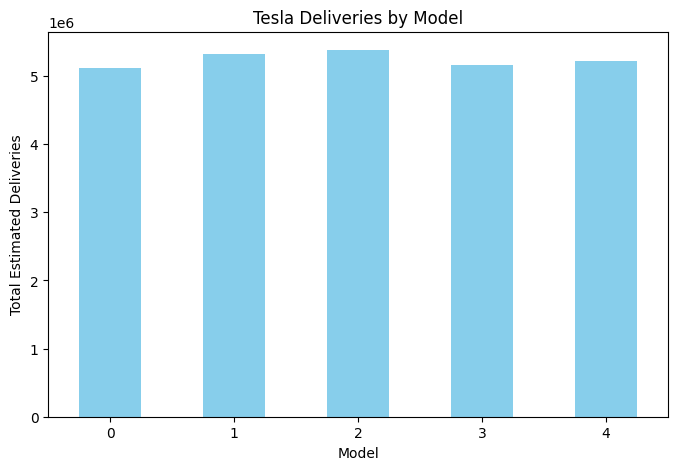

In [21]:
plt.figure(figsize=(8,5))

model_delivery = df.groupby("Model")["Estimated_Deliveries"].sum()

model_delivery.plot(kind='bar', color='skyblue')

plt.title("Tesla Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=0)

plt.show()

4.2 Deliveries by Region

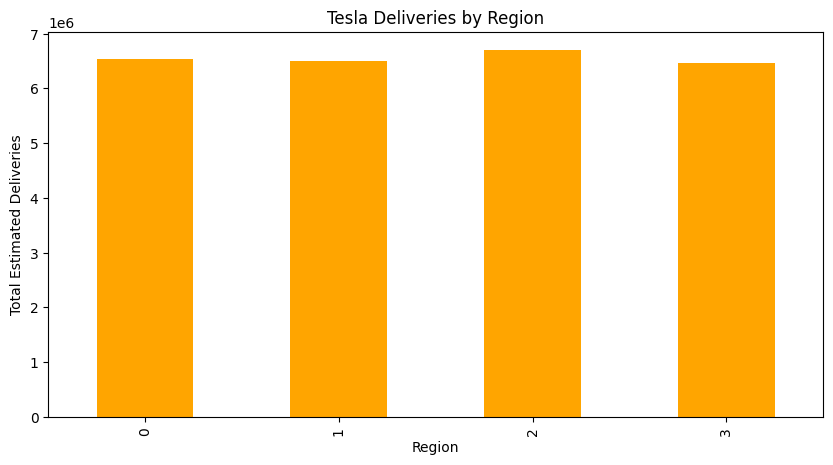

In [22]:
plt.figure(figsize=(10,5))

region_delivery = df.groupby("Region")["Estimated_Deliveries"].sum()

region_delivery.plot(kind='bar', color='orange')

plt.title("Tesla Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")

plt.show()

4.3 Correlation Heatmap

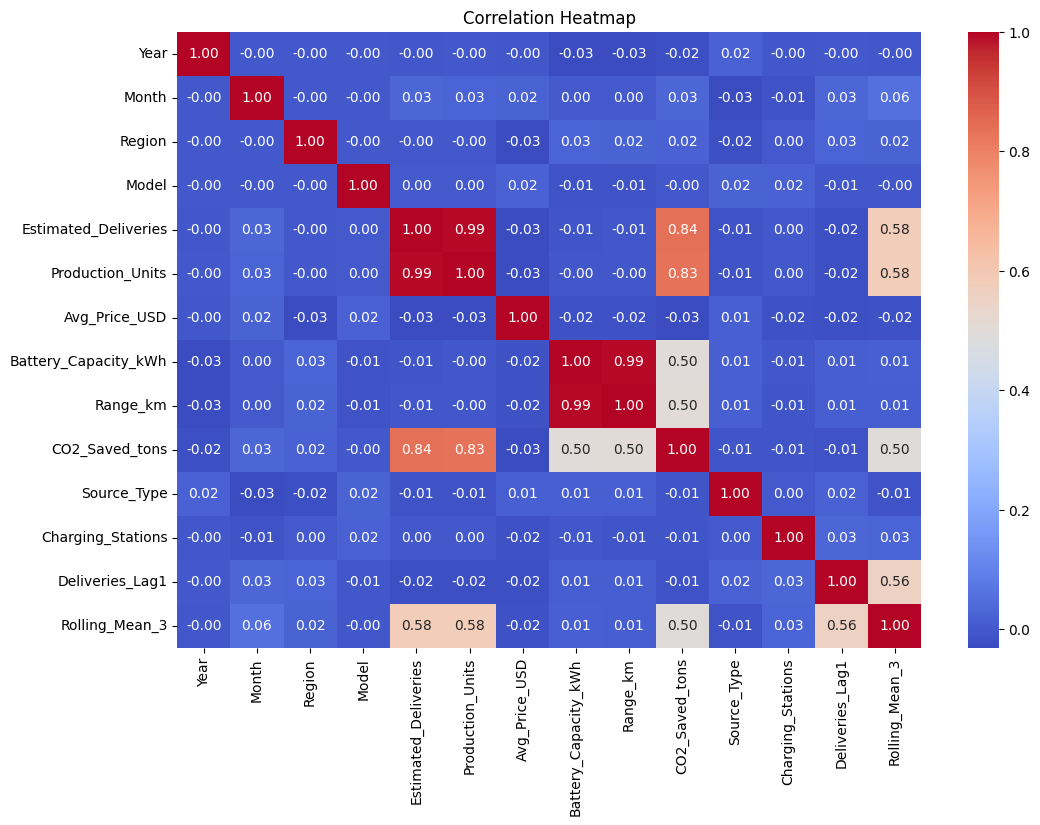

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

4.4 Production vs Deliveries Scatter Plot

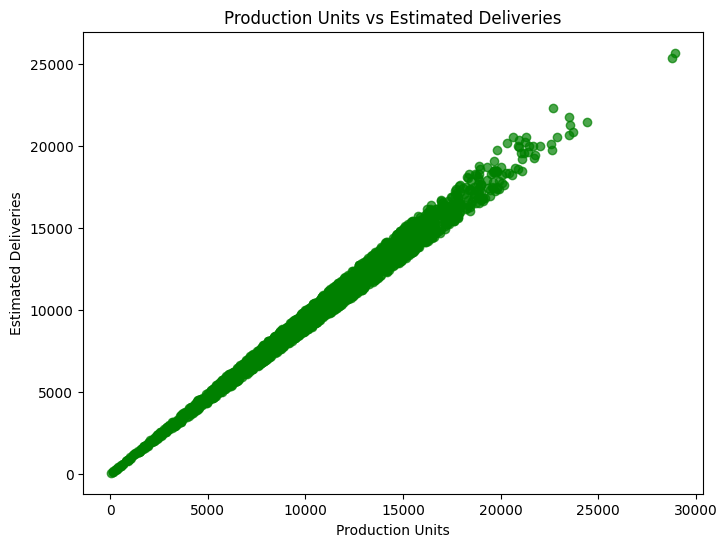

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"],
    alpha=0.7,
    color="green"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

4.5 Time Trend Line Chart

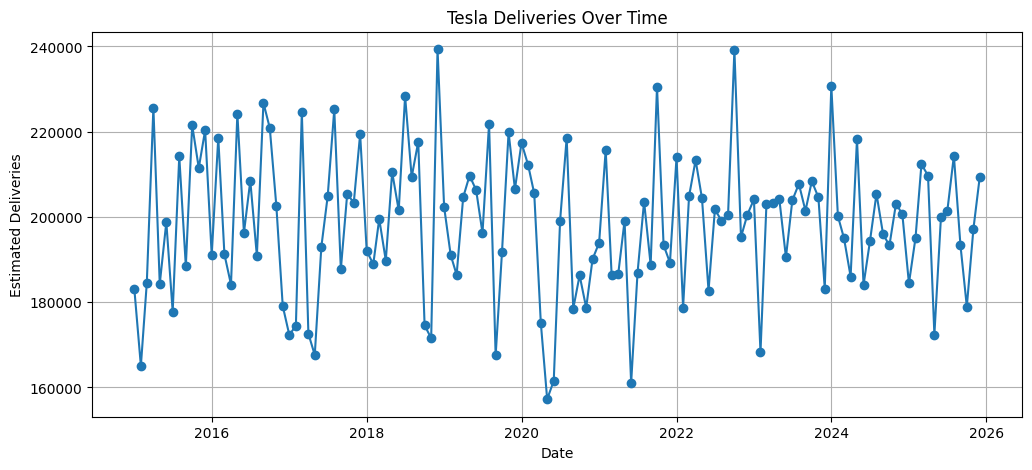

In [25]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

trend = df.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    trend.index,
    trend.values,
    marker='o'
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

Verify Correlation Requirement

In [26]:
correlation = df["Production_Units"].corr(df["Estimated_Deliveries"])

print("Correlation :", round(correlation,3))

Correlation : 0.994


**Section 5: Linear Regression Model**

In this step, the dataset is divided into training and testing sets using a chronological 80:20 split. A Linear Regression model is trained and evaluated using MAE, RMSE, and R² Score.

The dataset is split chronologically into 80% training and 20% testing data. A Linear Regression model is trained on the training set and evaluated using MAE, RMSE, and R² Score. The Actual vs Predicted plot shows how closely the model's predictions match the actual delivery values.

5.1 Define Features and Target

In [27]:
X = df.drop(columns=['Estimated_Deliveries', 'Date'])

y = df['Estimated_Deliveries']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (2640, 13)
Target Shape : (2640,)


5.2 Chronological Train-Test Split (80:20)

In [28]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 2112
Testing Samples : 528


5.3 Feature Scaling

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

5.4 Train Linear Regression Model

In [30]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


5.5 Make Predictions

In [31]:
y_pred_lr = lr_model.predict(X_test_scaled)

5.6 Model Evaluation

In [32]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")

print("MAE  :", round(mae_lr,2))
print("RMSE :", round(rmse_lr,2))
print("R² Score :", round(r2_lr,4))

Linear Regression Performance
MAE  : 323.16
RMSE : 392.22
R² Score : 0.9884


5.7 Actual vs Predicted Plot

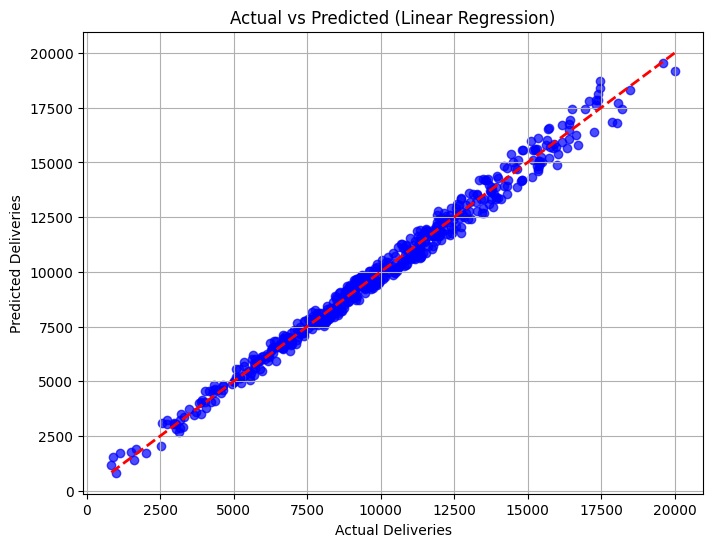

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.7,
    color='blue'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title("Actual vs Predicted (Linear Regression)")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.grid(True)

plt.show()

5.8 Save Metrics

In [34]:
linear_results = {
    "Model": "Linear Regression",
    "MAE": mae_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
}

linear_results

{'Model': 'Linear Regression',
 'MAE': 323.16184943049785,
 'RMSE': np.float64(392.22075078534766),
 'R2': 0.9884294134210871}

**Section 6: 5-Fold Cross Validation**

Cross Validation evaluates the model on multiple train-test splits to measure its stability and generalization performance. Here, a 5-Fold Cross Validation is performed using Linear Regression.

A 5-Fold Cross Validation is performed to evaluate the consistency of the Linear Regression model. The dataset is divided into five parts, and each part is used once for testing while the remaining parts are used for training. The average R² score and standard deviation indicate the model's overall performance and stability.

6.1: Import Required Libraries

In [35]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

6.2: Define 5-Fold Cross Validation

In [36]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

6.3: Perform Cross Validation

In [37]:
cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='r2'
)

6.4: Display R² Score of Each Fold

In [38]:
print("R² Score for Each Fold:\n")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

R² Score for Each Fold:

Fold 1: 0.9916
Fold 2: 0.9908
Fold 3: 0.9901
Fold 4: 0.9899
Fold 5: 0.9906


6.5: Mean and Standard Deviation

In [39]:
print("Mean R² Score :", round(cv_scores.mean(),4))

print("Standard Deviation :", round(cv_scores.std(),4))

Mean R² Score : 0.9906
Standard Deviation : 0.0006


6.6: Cross Validation Summary Table

In [40]:
cv_results = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "R² Score": cv_scores
})

cv_results

,Fold,R² Score
0,1,0.991559
1,2,0.990835
2,3,0.990078
3,4,0.989889
4,5,0.990575


**Section 7: Random Forest + GridSearchCV**

In this step, GridSearchCV is used to find the best hyperparameters for a Random Forest Regressor. The optimized model is trained and evaluated using MAE, RMSE, and R² Score. Feature importance is also visualized.

GridSearchCV tests different combinations of Random Forest parameters to find the best-performing model. The optimized model is evaluated using MAE, RMSE, and R² Score. Feature importance identifies the variables that contribute most to predicting Tesla deliveries.



7.1 Import Random Forest

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

7.2 Define Parameter Grid

In [42]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

param_grid

{'n_estimators': [50, 100], 'max_depth': [5, 10, None]}

7.3 Create Base Model

In [43]:
rf = RandomForestRegressor(random_state=42)

7.4 GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

7.5 Best Parameters

In [ ]:
print("Best Parameters:")

print(grid_search.best_params_)

7.6 Best Random Forest Model

In [ ]:
best_rf = grid_search.best_estimator_

7.7 Predictions

In [ ]:
y_pred_rf = best_rf.predict(X_test)

7.8 Model Evaluation

In [ ]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*35)

print("MAE :", round(rf_mae,2))
print("RMSE :", round(rf_rmse,2))
print("R² Score :", round(rf_r2,4))

7.9 Feature Importance

The importance of each feature is analyzed using the Random Forest model to identify the variables that contribute most to predicting Tesla deliveries.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

7.10 Top 10 Feature Importance Plot

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

7.11 Store Metrics

In [ ]:
rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

rf_results

**Section 8: ADF Stationarity Test**

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary. A stationary time series has constant statistical properties such as mean and variance over time, making it suitable for forecasting models.

8.1: Import ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

8.2: Perform ADF Test

In [ ]:
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Test Statistic :", adf_result[0])
print("p-value :", adf_result[1])
print("Number of Lags Used :", adf_result[2])
print("Number of Observations :", adf_result[3])

8.3: Critical Values

In [ ]:
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

8.4: Interpretation

In [ ]:
if adf_result[1] < 0.05:
    print("Conclusion:")
    print("The time series is Stationary.")
    print("Reject the Null Hypothesis (H0).")
else:
    print("Conclusion:")
    print("The time series is Non-Stationary.")
    print("Fail to Reject the Null Hypothesis (H0).")

**Section 9: Forecast Table & Model Comparison**

In this step, we compare the actual and predicted delivery values for the first 20 test records. We also compare the performance of the Linear Regression and Random Forest models using MAE, RMSE, and R² Score.

9.1 Forecast Table

In [ ]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

forecast_df.head()

9.2 Calculate Error Percentage

In [ ]:
forecast_df["Error %"] = (
    abs(forecast_df["Actual"] - forecast_df["Predicted"])
    / forecast_df["Actual"]
) * 100

forecast_df.head(20)

9.3 Display First 20 Records

In [ ]:
forecast_df.head(20)

9.4 Round Values

In [ ]:
forecast_df = forecast_df.round(2)

forecast_df.head(20)

9.5 Model Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        rf_mae
    ],
    "RMSE": [
        rmse_lr,
        rf_rmse
    ],
    "R² Score": [
        r2_lr,
        rf_r2
    ]
})

comparison

9.6 Highlight Best Model

In [ ]:
best_model = comparison.loc[
    comparison["R² Score"].idxmax()
]

print("Best Performing Model")
print(best_model)

**Conclusion**

## Conclusion

This project successfully implemented a complete machine learning pipeline, including preprocessing, visualization, feature engineering, regression modeling, hyperparameter tuning, and time series analysis. The Random Forest model achieved better prediction performance than Linear Regression.